In [20]:
from pathlib import Path

import os
import json
import subprocess
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from huggingface_hub import hf_hub_download
import MulensModel as mm
from matplotlib import gridspec

## 

In [2]:
BEGINNER_REPO_ID = "RGES-PIT/Beginner"
BEGINNER_FILENAME = "RMDC26_Beginner_Tier_test.parquet"
BEGINNER_LOCAL_DIR = "/home/bgordo11/DataChallenge26"  # reuse the same local data folder
EXPERIENCED_FILENAME = "RMDC26_Experienced_Tier_test.parquet"

beginner_parquet_path = hf_hub_download(
    repo_id=BEGINNER_REPO_ID,
    filename=BEGINNER_FILENAME,
    repo_type="dataset",
    local_dir=BEGINNER_LOCAL_DIR,
)

from huggingface_hub import HfApi


print(f"Beginner and Experienced tier data available locally at: {BEGINNER_LOCAL_DIR}")

experienced_parquet_path = "/home/bgordo11/DataChallenge26/RMDC26_Experienced_Tier_test.parquet"

print(f"Experienced tier data available locally at: {experienced_parquet_path}")
print(f"Beginner tier data available locally at: {beginner_parquet_path}")


Beginner and Experienced tier data available locally at: /home/bgordo11/DataChallenge26
Experienced tier data available locally at: /home/bgordo11/DataChallenge26/RMDC26_Experienced_Tier_test.parquet
Beginner tier data available locally at: /home/bgordo11/DataChallenge26/RMDC26_Beginner_Tier_test.parquet


In [3]:
con = duckdb.connect()

beginner_summary = con.execute(f"""
    SELECT COUNT(*) AS n_rows, COUNT(DISTINCT name) AS n_events
    FROM read_parquet('{beginner_parquet_path}')
""").fetchdf()
beginner_summary

,n_rows,n_events
0,9230048,188


In [4]:
# Column names in the parquet. Beginner-tier names are the defaults; if the experienced
# tier uses different names, override them here after running the schema check below.
COLUMN_MAP = {
    "name": "name",
    "time": "bjd",
    "filt": "filt",
    "flux": "flux_uJy",
    "flux_err": "flux_err_uJy",
    "sat": "saturation_flag",   # optional - ignored if the column does not exist
}

_schema_cache = {}

def describe_parquet(parquet_path):
    """Column names/types of a parquet file (reads metadata only, cached)."""
    if parquet_path not in _schema_cache:
        with duckdb.connect() as c:
            _schema_cache[parquet_path] = c.execute(
                f"DESCRIBE SELECT * FROM read_parquet('{parquet_path}')"
            ).fetchdf()
    return _schema_cache[parquet_path]

def load_event(event_name, parquet_path=None, exclude_saturated=True, column_map=None):
    """Load one event's light curve (bjd, filt, flux, flux_err[, saturation_flag]) from either tier."""
    cm = {**COLUMN_MAP, **(column_map or {})}
    parquet_path = parquet_path or experienced_parquet_path
    available = set(describe_parquet(parquet_path)["column_name"])

    required = ("name", "time", "filt", "flux", "flux_err")
    missing = [cm[k] for k in required if cm[k] not in available]
    if missing:
        raise KeyError(
            f"Columns {missing} not found in {parquet_path}. Available: {sorted(available)}. "
            "Edit COLUMN_MAP (or pass column_map=) to match."
        )

    has_sat = cm["sat"] in available
    select = f"{cm['time']} AS bjd, {cm['filt']} AS filt, {cm['flux']} AS flux, {cm['flux_err']} AS flux_err"
    if has_sat:
        select += f", {cm['sat']} AS saturation_flag"

    query = f"""
        SELECT {select}
        FROM read_parquet('{parquet_path}')
        WHERE {cm['name']} = '{event_name}'
    """
    if exclude_saturated and has_sat:
        query += f" AND {cm['sat']} = 0"
    query += " ORDER BY bjd"

    with duckdb.connect() as local_con:
        df = local_con.execute(query).fetchdf()
    return df

# Backwards-compatible name used by the older cells
load_beginner_event = load_event

def split_by_filter(lc):
    return {filt: group.reset_index(drop=True) for filt, group in lc.groupby("filt")}


In [5]:
### SCHEMA CHECK: run this once on the experienced parquet ###
# If the column names differ from the beginner tier, update COLUMN_MAP in the cell above.
display(describe_parquet(experienced_parquet_path)[["column_name", "column_type"]])

with duckdb.connect() as _c:
    display(_c.execute(f"""
        SELECT COUNT(*) AS n_rows, COUNT(DISTINCT {COLUMN_MAP['name']}) AS n_events
        FROM read_parquet('{experienced_parquet_path}')
    """).fetchdf())


,column_name,column_type
0,name,VARCHAR
1,l_deg,DOUBLE
2,b_deg,DOUBLE
3,ra_deg,DOUBLE
4,dec_deg,DOUBLE
5,bjd,DOUBLE
6,filt,VARCHAR
7,flux_uJy,DOUBLE
8,flux_err_uJy,DOUBLE
9,extinction,DOUBLE


,n_rows,n_events
0,102885552,2079


## How the event fitting function works: 
1. PSPL: Does a simple PSPL fit for $t_0$, $t_E$, and $\mu_0$. When it does this, I tried a couple things to get good starting values for the fit, which really helped speed things up, such as trying multiple $t_0$ values as an initial check

2. $\chi_{red}^2$ per point: Calculates $\chi^2$ per data point within a window of 1.5 days, and finds the average. If this is above 3-5, there is some anomoly in the lightcurve

3. Parallax: If the $t_E$ is greater than 15 days, runs the PSPL+parallax fit (with the parallax reference time $t_{0,par}$ held fixed at the PSPL $t_0$) and updates if $\Delta\chi^2$ > 11.8 ($3\sigma$). The fitted $\pi_{E,N}$ and $\pi_{E,E}$ are written to the summary file

4. 2L1S: sample over a grid of s and q, and then start the 2L1S fit

5. Outputs: each event is written to the summary text file  and to a microlens-submit CSV 

** NOTE! I WOULD DEFINTELY CHANGE MANY THINGS ABOUT THIS, just did not have the time to do it before deadline. But! The data challenge really helped in growing my understanding on how to model microlensing events effectively, and I have been able to carry these lessons learned over to my actual research. Of the various things I would change on a subsequent attempt, here are a few that stick out:
1. There is no actual anomaly finder involved, so planetary anomalies cannot be characterized at all. It just sort of generally flags an event with a potential anomaly for further analysis (which I suppose is not a bad starting point)

2. So I currently have it set up where it only runs higher-order effects or binary source/lens if the initial chi2 is above some threshold. My idea for this was to basically allow time to be saved when running huge numbers of events, so that an event that is modeled well by a simple pspl does not get modeled 4 more times. However, if I had unlimited time and better compute, I'd like to fit everything and compare chi2 at the end. 

3. There is no parallax fit for multi-source/lens systems. This is an obvious problem for having good fits


In [11]:
### Hierarchical Model Fitting & Anomaly Detection ###
def fit_event_hierarchy(fit_data, df_band, anomaly_threshold=4.0, window_days=1.5, coords="18:00:00 -30:00:00", max_iter=10):
    """
    Fits PSPL baseline, tests for Parallax (if tE > 15d), calculates rolling chi2,
    and tests Binary source and lens grid search if local chi2 threshold is exceeded.
    """

    ### Setup list that collects the chi2 values for each model tested 
    attempted_fits = []

    def log_attempt(name, chi2, num_params):
        dof = len(df_band) - num_params
        chi2_red = chi2 / dof if dof > 0 else 0.0
        attempted_fits.append({
            "model_type": name,
            "chi2": chi2,
            "dof": dof,
            "chi2_red": chi2_red
        })
        return dof, chi2_red

    ###  Baseline PSPL Fit ###
    def chi2_pspl(params):
        t_0, u_0, t_E = params
        if t_E <= 0 or u_0 <= 0:
            return np.inf
        try:
            model = mm.Model({"t_0": t_0, "u_0": abs(u_0), "t_E": t_E}, coords=coords)
            event = mm.Event(datasets=[fit_data], model=model, coords=coords)
            chi2 = event.get_chi2()
            return chi2 if np.isfinite(chi2) else np.inf
        except Exception:
            return np.inf

    # Smooth out single-point noise spikes 
    window_pts = min(15, max(3, len(df_band) // 20))
    smoothed_flux = (df_band["flux"].rolling(window=window_pts, center=True, min_periods=1).median())

    # Estimate baseline flux and peak magnification
    flux_baseline = np.median(df_band["flux"])

    # Multi-Start Grid over Candidate Peaks across Gaps
    brightest_idx = smoothed_flux.nlargest(20).index
    candidate_t0s = df_band.loc[brightest_idx, "bjd"].values

    distinct_t0s = []
    for t0 in candidate_t0s:
        if not any(abs(t0 - existing) < 5.0 for existing in distinct_t0s):
            distinct_t0s.append(t0)
        if len(distinct_t0s) >= 5:
            break

    best_init_chi2 = np.inf
    best_initial_guess = None

    for candidate_t0 in distinct_t0s:

        # Peak flux within 2 days of candidate t0
        peak_flux = df_band.loc[(df_band["bjd"] - candidate_t0).abs() < 2.0,"flux"].max()

        # Flux ratio is used as a rough initial magnification estimate.
        # Blend flux means this is only an approximate starting guess.
        A_max = peak_flux / flux_baseline if flux_baseline > 0 else 1.05
        A_max = max(A_max, 1.05)

        # Approximate PSPL relation:
        # A(u) = (u^2 + 2) / (u * sqrt(u^2 + 4))
        # Invert numerically to obtain an initial u0.
        from scipy.optimize import brentq

        def magnification(u):
            return (u**2 + 2.0) / (u * np.sqrt(u**2 + 4.0))

        try:
            u0_guess = brentq(lambda u: magnification(u) - A_max, 1e-5, 1.0)
        except ValueError:
            u0_guess = 0.3

        # Estimate tE from the duration of elevated flux
        threshold_flux = flux_baseline + 0.5 * (peak_flux - flux_baseline)
        peak_region = df_band[df_band["flux"] > threshold_flux]
        tE_guess = (max(peak_region["bjd"].max()- peak_region["bjd"].min(),0.5) if len(peak_region) > 2 else 2.0)

        guess = [candidate_t0, u0_guess, tE_guess] #list with all of our guesses
        chi2_candidate = chi2_pspl(guess)

        if chi2_candidate < best_init_chi2:
            best_init_chi2 = chi2_candidate
            best_initial_guess = guess

    if best_initial_guess is None:
        best_initial_guess = [
            df_band.loc[smoothed_flux.idxmax(), "bjd"],
            0.3,
            2.0
        ]

    if best_initial_guess is None:
        best_initial_guess = [df_band.loc[smoothed_flux.idxmax(), "bjd"], 0.3, 2.0]

    # Minimize call #
    bounds = [(None, None), (1e-5, 10.0), (0.001, 500.0)]
    res_pspl = minimize(chi2_pspl, best_initial_guess, method="Nelder-Mead", bounds=bounds)
    
    t_0_fit, u_0_fit, t_E_fit = res_pspl.x
    chi2_val = res_pspl.fun

    best_model_type = "PSPL"
    best_model = mm.Model({"t_0": t_0_fit, "u_0": u_0_fit, "t_E": t_E_fit}, coords=coords)

    ## Records PSPL chi2 ##
    log_attempt("PSPL", chi2_val, num_params=3)

    ###  Test Parallax (if tE > 15 days), two more parameters (pi_E_N, pi_E_E) ###
    t_0_par_ref = float(t_0_fit)  # fixed parallax reference time (PSPL t_0)
    if t_E_fit > 15.0:
        par_init = [t_0_fit, u_0_fit, t_E_fit, 0.0, 0.0]
        par_bounds = [(None, None), (1e-5, 10.0), (0.001, 500.0), (-2.0, 2.0), (-2.0, 2.0)]

        def chi2_parallax(params):
            t_0, u_0, t_E, pi_E_N, pi_E_E = params
            if t_E <= 0 or u_0 <= 0: return np.inf
            try:
                m = mm.Model({"t_0": t_0, "u_0": abs(u_0), "t_E": t_E, "pi_E_N": pi_E_N, "pi_E_E": pi_E_E, "t_0_par": t_0_par_ref}, coords=coords)
                return mm.Event(datasets=[fit_data], model=m, coords=coords).get_chi2()
            except Exception: return np.inf

        res_par = minimize(chi2_parallax, par_init, method="Nelder-Mead", bounds=par_bounds, options={"maxiter": max_iter, "fatol": 1.0})

        ## Records Parallax chi2 ##
        log_attempt("PSPL+parallax", res_par.fun, num_params=5)

        ## Checks to see if parallax is a significant improvement over PSPL ##
        if (chi2_val - res_par.fun) > 11.83:  # 3-sigma improvement
            best_model_type = "PSPL+parallax"
            chi2_val = res_par.fun
            t0_p, u0_p, tE_p, pi_N, pi_E = res_par.x
            best_model = mm.Model({"t_0": t0_p, "u_0": u0_p, "t_E": tE_p, "pi_E_N": pi_N, "pi_E_E": pi_E, "t_0_par": t_0_par_ref}, coords=coords)
            t_0_fit, u_0_fit, t_E_fit = t0_p, u0_p, tE_p

    ### Initial Rolling Chi2 Calculation (Baseline + Parallax Model) ###
    times = fit_data.time
    chi2_points = mm.Event(datasets=[fit_data], model=best_model, coords=coords).get_chi2_per_point()[0]
    df_chi2 = pd.DataFrame({'bjd': times, 'chi2': chi2_points}).sort_values('bjd').reset_index(drop=True)

    effective_window = max(0.2, min(window_days, 0.1 * t_E_fit))  # Ensure window is at least 0.2 days or 10% of t_E
    rolling_chi2_red = []
    for t in df_chi2['bjd']:
        mask = (df_chi2['bjd'] >= t - effective_window / 2.0) & (df_chi2['bjd'] <= t + effective_window / 2.0)
        window_data = df_chi2.loc[mask]
        n_pts = len(window_data)
        rolling_chi2_red.append(window_data['chi2'].sum() / n_pts if n_pts > 3 else 0.0)

    df_chi2['rolling_chi2'] = rolling_chi2_red
    max_local_chi2 = df_chi2['rolling_chi2'].max()

    ### Binary lens and Binary source fitting (if anomaly threshold exceeded) ###
    ### Adds 3 new parameters for binary lens (s, q, alpha) or 2 new parameters for binary source (t0_2, u0_2) ###

    if max_local_chi2 > anomaly_threshold:
        # Binary lens (2L1S) fit #
        ## GRID SEARCH OVER (s, q, alpha)##
        s_grid = np.logspace(np.log10(0.3), np.log10(3.0), 8)
        q_grid = np.logspace(-4, 0, 8)
        alpha_grid = np.array([0.0, 90.0, 180.0, 270.0])

        best_grid_chi2 = np.inf
        best_grid_params = None

        for s_val in s_grid:
            for q_val in q_grid:
                for alpha_val in alpha_grid:
                    try:
                        m_grid = mm.Model(
                            {"t_0": t_0_fit, "u_0": u_0_fit, "t_E": t_E_fit, 
                             "s": s_val, "q": q_val, "alpha": alpha_val}, 
                            coords=coords
                        )
                        m_grid.default_magnification_method = "point_source"
                        grid_chi2 = mm.Event(datasets=[fit_data], model=m_grid, coords=coords).get_chi2()

                        if grid_chi2 < best_grid_chi2:
                            best_grid_chi2 = grid_chi2
                            best_grid_params = [t_0_fit, u_0_fit, t_E_fit, s_val, q_val, alpha_val]
                    except Exception:
                        continue

        ### NELDER-MEAD REFINEMENT FROM BEST GRID SPOT ###
        if best_grid_params is not None:
            bin_bounds = [
                (t_0_fit - 3*t_E_fit, t_0_fit + 3*t_E_fit), 
                (1e-4, 5.0), 
                (0.01, 300.0), 
                (0.1, 10.0), 
                (1e-6, 1.0), 
                (0.0, 360.0)
            ]

            def chi2_binary_lens(params):
                t_0, u_0, t_E, s, q, alpha = params
                if t_E <= 0 or u_0 <= 0 or s <= 0 or q <= 0: return np.inf
                try:
                    m = mm.Model(
                        {"t_0": t_0, "u_0": abs(u_0), "t_E": t_E, 
                         "s": s, "q": q, "alpha": alpha}, 
                        coords=coords
                    )
                    m.default_magnification_method = "point_source"
                    return mm.Event(datasets=[fit_data], model=m, coords=coords).get_chi2()
                except Exception:
                    return np.inf

            res_2L1S = minimize(
                chi2_binary_lens, 
                best_grid_params, 
                method="Nelder-Mead", 
                bounds=bin_bounds, 
                options={"maxiter": max_iter, "fatol": 1.0}
            )
            best_2L1S_chi2 = res_2L1S.fun
            ### Records 2L1S chi2 ###
            log_attempt("2L1S (Binary Lens)", best_2L1S_chi2, num_params=6)
            
            ### BINARY SOURCE (1L2S) FIT ###
            # Find peak time of the anomaly to initialize t_0_2 for second source
            anomaly_peak_t0 = df_chi2.loc[df_chi2["rolling_chi2"].idxmax(), "bjd"]

            init_1L2S = [t_0_fit, u_0_fit, anomaly_peak_t0, 0.1, t_E_fit]
            bounds_1L2S = [
                (t_0_fit - 30.0, t_0_fit + 30.0),  # t_0_1
                (1e-4, 5.0),  # u_0_1
                (df_band["bjd"].min(), df_band["bjd"].max()),  # t_0_2
                (1e-4, 5.0),  # u_0_2
                (0.1, 300.0),  # t_E
            ]

            def chi2_binary_source(params):
                t_0_1, u_0_1, t_0_2, u_0_2, t_E = params
                if t_E <= 0 or u_0_1 <= 0 or u_0_2 <= 0:
                    return np.inf
                try:
                    m = mm.Model(
                        {
                            "t_0_1": t_0_1,
                            "u_0_1": abs(u_0_1),
                            "t_0_2": t_0_2,
                            "u_0_2": abs(u_0_2),
                            "t_E": t_E,
                        },
                        coords=coords,
                    )
                    return mm.Event(
                        datasets=[fit_data], model=m, coords=coords
                    ).get_chi2()
                except Exception:
                    return np.inf

            res_1L2S = minimize(
                chi2_binary_source,
                init_1L2S,
                method="Nelder-Mead",
                bounds=bounds_1L2S,
                options={"maxiter": max_iter, "fatol": 1.0},
            )
            best_1L2S_chi2 = res_1L2S.fun

            ### Records 1L2S chi2 ###
            log_attempt("1L2S (Binary Source)", best_1L2S_chi2, num_params=5)

            ### COMPARE MODELS AGAINST BASELINE ###
            best_anomaly_chi2 = min(best_2L1S_chi2, best_1L2S_chi2)

            # Require minimum Delta Chi2 > 30.0 improvement over PSPL/Parallax
            if (chi2_val - best_anomaly_chi2) > 30.0:
                chi2_val = best_anomaly_chi2

                if best_2L1S_chi2 <= best_1L2S_chi2:
                    best_model_type = "2L1S (Binary Lens)"
                    t0_b, u0_b, tE_b, s_b, q_b, alpha_b = res_2L1S.x
                    best_model = mm.Model(
                        {
                            "t_0": t0_b,
                            "u_0": u0_b,
                            "t_E": tE_b,
                            "s": s_b,
                            "q": q_b,
                            "alpha": alpha_b,
                        },
                        coords=coords,
                    )
                    t_0_fit, u_0_fit, t_E_fit = t0_b, u0_b, tE_b
                else:
                    best_model_type = "1L2S (Binary Source)"
                    t01_s, u01_s, t02_s, u02_s, tE_s = res_1L2S.x
                    best_model = mm.Model(
                        {
                            "t_0_1": t01_s,
                            "u_0_1": u01_s,
                            "t_0_2": t02_s,
                            "u_0_2": u02_s,
                            "t_E": tE_s,
                        },
                        coords=coords,
                    )
                    t_0_fit, u_0_fit, t_E_fit = t01_s, u01_s, tE_s

    ### Final Chi2 Calculation for the best model (after anomaly fitting) ###
    final_chi2_pts = mm.Event(datasets=[fit_data], model=best_model, coords=coords).get_chi2_per_point()[0]
    df_chi2['chi2'] = final_chi2_pts

    effective_window = max(0.2, min(window_days, 0.1 * t_E_fit))  # Ensure window is at least 0.2 days or 10% of t_E
    rolling_chi2_red = []
    for t in df_chi2['bjd']:
        mask = (df_chi2['bjd'] >= t - effective_window / 2.0) & (df_chi2['bjd'] <= t + effective_window / 2.0)
        window_data = df_chi2.loc[mask]
        n_pts = len(window_data)
        rolling_chi2_red.append(window_data['chi2'].sum() / n_pts if n_pts > 3 else 0.0)

    df_chi2['rolling_chi2'] = rolling_chi2_red
    max_local_chi2 = df_chi2['rolling_chi2'].max()

    # Append "+anomaly" ONLY if max_local_chi2 is STILL above threshold 
    # AND the best model is not already accepted as a full 2L1S binary model
    if (max_local_chi2 > anomaly_threshold) and ("2L1S" not in best_model_type) and ("1L2S" not in best_model_type):
        best_model_type += "+anomaly"

    ### Final degrees of Freedom and reduced chi2 ###
    best_params = dict(best_model.parameters.parameters)
    num_params = len([k for k in best_params if k not in ("t_0_par", "t_0_kep")])
    dof = len(df_band) - num_params
    chi2_red = chi2_val / dof if dof > 0 else 0.0

    ### Extra info for the summary file and the microlens-submit CSV ###
    flux_source, flux_blend = [np.nan], np.nan
    try:
        fs, fb = mm.Event(datasets=[fit_data], model=best_model, coords=coords).get_flux_for_dataset(0)
        flux_source = [float(x) for x in np.atleast_1d(fs)]
        flux_blend = float(fb)
    except Exception:
        pass

    extras = {
        "params": {k: float(v) for k, v in best_params.items()},
        "pi_E_N": float(best_params.get("pi_E_N", np.nan)),
        "pi_E_E": float(best_params.get("pi_E_E", np.nan)),
        "t_0_par": float(best_params.get("t_0_par", np.nan)),
        "flux_source": flux_source,
        "flux_blend": flux_blend,
        "attempted_fits": attempted_fits,
    }

    return best_model_type, best_model, chi2_val, dof, chi2_red, t_0_fit, u_0_fit, t_E_fit, df_chi2, extras


### SUMMARY FILE FORMAT + I/O ###
# Columns: event_id, best_fit_model, chi2, dof, chi2_red, t_0, u_0, t_E, pi_E_N, pi_E_E
# pi_E_N / pi_E_E are 'nan' unless the selected model includes parallax.
# Older 8-column summary files are still read; they are padded with nan when rewritten.

SUMMARY_HEADER = (
    f"{'event_id':<25} {'best_fit_model':<22} {'chi2':<12} {'dof':<10} {'chi2_red':<10} "
    f"{'t_0':<18} {'u_0':<10} {'t_E':<10} {'pi_E_N':<10} {'pi_E_E':<10}\n"
)
SUMMARY_RULE = "=" * 138 + "\n"


def format_summary_line(event_id, model_type, chi2, dof, chi2_red, t_0, u_0, t_E,
                        pi_E_N=np.nan, pi_E_E=np.nan):
    return (
        f"{event_id:<25} {model_type:<22} {chi2:<12.1f} {int(dof):<10d} {chi2_red:<10.2f} "
        f"{t_0:<18.4f} {u_0:<10.4f} {t_E:<10.4f} {pi_E_N:<10.4f} {pi_E_E:<10.4f}\n"
    )


def _is_number(tok):
    try:
        float(tok)
        return True
    except ValueError:
        return False


def parse_summary_line(line):
    """Parse one summary line (old 6-number or new 8-number tail). Returns a dict or None."""
    parts = line.split()
    n_tail = 0
    while n_tail < len(parts) - 1 and _is_number(parts[-1 - n_tail]):
        n_tail += 1
    if n_tail < 6 or len(parts) - n_tail < 2:
        return None
    vals = [float(x) for x in parts[len(parts) - n_tail:]]
    head = parts[: len(parts) - n_tail]
    chi2, dof, chi2_red, t_0, u_0, t_E = vals[:6]
    pi_N, pi_E = (vals[6], vals[7]) if n_tail >= 8 else (np.nan, np.nan)
    return {
        "event_id": head[0], "model": " ".join(head[1:]),
        "chi2": chi2, "dof": dof, "chi2_red": chi2_red,
        "t_0": t_0, "u_0": u_0, "t_E": t_E, "pi_E_N": pi_N, "pi_E_E": pi_E,
    }


### FUNCTION THAT LOADS THE EXISTING RESULTS ###

def load_existing_results(summary_file_path):
    """Reads the existing summary file into {event_id: {'model', 'chi2_red', 'raw_line'}}.

    raw_line is always re-formatted to the current column layout.
    """
    existing_data = {}
    if not os.path.exists(summary_file_path):
        return existing_data

    with open(summary_file_path, "r") as f:
        for line in f:
            line_str = line.strip()
            if not line_str or line_str.startswith("event_id") or line_str.startswith("="):
                continue
            rec = parse_summary_line(line_str)
            if rec is None:
                continue
            existing_data[rec["event_id"]] = {
                "model": rec["model"],
                "chi2_red": rec["chi2_red"],
                "raw_line": format_summary_line(
                    rec["event_id"], rec["model"], rec["chi2"], rec["dof"], rec["chi2_red"],
                    rec["t_0"], rec["u_0"], rec["t_E"], rec["pi_E_N"], rec["pi_E_E"],
                ),
            }
    return existing_data


def write_summary(summary_file_path, records):
    """records: {event_id: formatted line}. Rewrites the whole file (header + rows)."""
    with open(summary_file_path, "w") as f:
        f.write(SUMMARY_HEADER)
        f.write(SUMMARY_RULE)
        for line in records.values():
            f.write(line if line.endswith("\n") else line + "\n")


In [14]:
### 07-30-26: PUT THE BATCH FITTING LOOP INTO A FUNCTION ###

def run_batch_fitting(
    run_type="test",
    tier="experienced",
    n_events=4,
    fit_band="F146",
    anomaly_threshold=4.0,
    event_coords="18:00:00 -30:00:00",
    good_chi2_min=1.0,
    good_chi2_max=1.5,
    max_iter=10,
    base_data_dir="/home/bgordo11/DataChallenge26",
    parquet_path=None,  # defaults to the parquet matching `tier`
    submission_csv=None,  # defaults to <base_data_dir>/submission_solutions_<tier>.csv
):
    """
    Parameters:
    -----------
    run_type : str ('test' or 'real')
        Controls destination directories and summary file targets.
    tier : str ('beginner' or 'experienced')
        Selects the default parquet file and names the plot folder / submission CSV.
    n_events : int or None
        Number of events to fit. Set to None to run all events.
    """

    if tier.lower() not in ("beginner", "experienced"):
        raise ValueError("tier must be 'beginner' or 'experienced'")

    # Use global path variable if not explicitly passed
    if parquet_path is None:
        parquet_path = experienced_parquet_path if tier.lower() == "experienced" else beginner_parquet_path

    ### Finding the right path ####
    if run_type.lower() == "test":
        plot_dir = "Test-Output-plots"
        summary_file = os.path.join(base_data_dir, "test_summary.txt")
    elif run_type.lower() in ["real", "production"]:
        plot_dir = f"Events-{tier.capitalize()}-plots"
        summary_file = os.path.join(base_data_dir, "summary_results.txt")
    else:
        raise ValueError("run_type must be either 'test' or 'real'")

    os.makedirs(plot_dir, exist_ok=True)

    rows_json = os.path.join(base_data_dir, f"submission_rows_{tier.lower()}_{run_type.lower()}.json")
    if submission_csv is None:
        submission_csv = os.path.join(base_data_dir, f"submission_solutions_{tier.lower()}_{run_type.lower()}.csv")

    print(
        f"  RUN CONFIGURATION: [{run_type.upper()} MODE]\n"
        f" • Plot Directory: {plot_dir}\n"
        f" • Summary File:  {summary_file}\n"
        f" • Submission CSV: {submission_csv}\n"
        + "=" * 80
    )

    ##### LOAD EXISTING RESULTS & EVENT LIST #####
    existing_results = load_existing_results(summary_file)

    with duckdb.connect() as con:
        event_df = con.execute(f"""
            SELECT DISTINCT name 
            FROM read_parquet('{parquet_path}')
            ORDER BY name
        """).fetchdf()

    unique_events = event_df["name"].tolist()
    events_to_process = (
        unique_events[:n_events] if n_events is not None else unique_events
    )

    # Start from the existing summary so events not touched in this run are kept (append/update)
    final_summary_records = {eid: rec["raw_line"] for eid, rec in existing_results.items()}
    submission_rows = load_submission_rows(rows_json)

    ##### BATCH LOOP ####
    for event_id in events_to_process:

        # Skip logic
        if event_id in existing_results:
            cached_chi2_red = existing_results[event_id]["chi2_red"]

            if (
                pd.notna(cached_chi2_red)
                and good_chi2_min <= cached_chi2_red <= good_chi2_max
            ):
                print(
                    f" Skipping [{event_id}]: Good fit already exists"
                    f" (chi2_red = {cached_chi2_red:.2f})"
                )
                final_summary_records[event_id] = existing_results[event_id][
                    "raw_line"
                ]
                continue
            else:
                print(
                    f"Re-running [{event_id}]: Previous chi2_red"
                    f" ({cached_chi2_red}) was poor or invalid."
                )
        else:
            print(f"Fitting [{event_id}]: No existing entry found.")

        # Load light curve
        lc = load_event(event_id, parquet_path=parquet_path, exclude_saturated=True)
        bands = split_by_filter(lc)

        if fit_band not in bands or bands[fit_band].empty:
            print(
                f"Skipping {event_id}: No valid observations in band"
                f" {fit_band}"
            )
            continue

        df_band = bands[fit_band]
        fit_data = mm.MulensData(
            data_list=[
                df_band["bjd"].values,
                df_band["flux"].values,
                df_band["flux_err"].values,
            ],
            phot_fmt="flux",
            bandpass=fit_band,
        )

        ### FIT EVENT ###
        model_type, best_model, chi2_val, dof, chi2_red, t_0_fit, u_0_fit, t_E_fit, df_chi2, extras = fit_event_hierarchy(
            fit_data, df_band, anomaly_threshold=anomaly_threshold, coords=event_coords, max_iter=max_iter)
        
        best_event = mm.Event(datasets=[fit_data], model=best_model, coords=event_coords)

        # Logging output #
        flagged_epochs = df_chi2[df_chi2["rolling_chi2"] > anomaly_threshold]
        if not flagged_epochs.empty:
            print(
                f"Potential anomaly detected in {event_id}! Found"
                f" {len(flagged_epochs)} epochs above threshold."
            )
        else:
            print(
                f"✓ No significant anomalies detected for {event_id} at"
                f" threshold {anomaly_threshold}."
            )

        # Generate plot
        fig = plt.figure(figsize=(10, 8))
        gs = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.12)

        ax_top = fig.add_subplot(gs[0])
        ax_mid = fig.add_subplot(gs[1], sharex=ax_top)
        ax_bot = fig.add_subplot(gs[2], sharex=ax_top)

        # Top panel
        plt.sca(ax_top)
        fit_data.plot(
            phot_fmt="flux",
            subtract_2460000=True,
            alpha=0.15,
            zorder=1,
            label=f"{fit_band} data",
            ms=2,
        )

        ## Prevents the model from being plotted too far outside the data range ##
        N_TE = 10.0
        t_min_data, t_max_data = fit_data.time.min(), fit_data.time.max()
        t_start = max(t_min_data, t_0_fit - N_TE * t_E_fit)
        t_stop = min(t_max_data, t_0_fit + N_TE * t_E_fit)

        best_event.plot_model(
            phot_fmt="flux",
            subtract_2460000=True,
            t_start=t_start,
            t_stop=t_stop,
            n_epochs=2000,
            color="red",
            linewidth=1,
            zorder=10,
            label=f"{model_type} fit",
        )
        ax_top.legend(loc="upper right")
        ax_top.set_ylabel("Flux (uJy)")
        ax_top.set_title(f"Event: {event_id} ({model_type} Fit)")

        ## RESIDUALS PANEL (MIDDLE PANNEL) ##
        plt.sca(ax_mid)
        best_event.plot_residuals(subtract_2460000=True, zorder=1, ms=2, alpha=0.15)
        ax_mid.axhline(0, color="gray", linestyle="--", alpha=0.7)
        ax_mid.set_ylabel("Residuals (uJy)")

        # ROLLING CHI2 PANEL (BOTTOM PANEL) ##
        plt.sca(ax_bot)
        ax_bot.plot(
            df_chi2["bjd"] - 2460000,
            df_chi2["rolling_chi2"],
            color="blue",
            label=r"Sliding-window $\chi^2$",
            alpha=0.7,
        )
        ax_bot.axhline(
            anomaly_threshold,
            color="red",
            linestyle=":",
            label="Anomaly Threshold",
        )
        ax_bot.fill_between(
            df_chi2["bjd"] - 2460000,
            df_chi2["rolling_chi2"],
            anomaly_threshold,
            where=df_chi2["rolling_chi2"] > anomaly_threshold,
            color="red",
            alpha=0.3,
        )
        ax_bot.set_xlabel("BJD - 2460000")
        ax_bot.set_ylabel(r"Local $\chi^2_{\mathrm{red}}$ / point")
        ax_bot.legend(loc="upper right")

        # Zoom window
        zoom_margin = 1.5 * t_E_fit
        ax_top.set_xlim(
            (t_0_fit - zoom_margin) - 2460000, (t_0_fit + zoom_margin) - 2460000
        )

        plt.tight_layout()

        filename_suffix = "_fit_test.pdf" if run_type == "test" else "_fit.pdf"
        plot_path = os.path.join(
            plot_dir,
            f"{event_id}_{model_type.replace(' ', '_')}{filename_suffix}",
        )
        plt.savefig(plot_path, format="pdf", dpi=300, bbox_inches="tight")
        plt.close(fig)

        # Record summary text line
        final_summary_records[event_id] = format_summary_line(
            event_id, model_type, chi2_val, dof, chi2_red, t_0_fit, u_0_fit, t_E_fit,
            extras["pi_E_N"], extras["pi_E_E"],
        )
        submission_rows[event_id] = build_submission_row(
            event_id, model_type, extras, chi2_val, chi2_red, n_data=len(df_band), fit_band=fit_band
        )

        print(
            f"✓ [{event_id}] Updated fit: {model_type} | Saved plot | chi2/dof ="
            f" {chi2_red:.2f}"
        )

    ###  WRITE UPDATED SUMMARY + SUBMISSION CSV ###
    write_summary(summary_file, final_summary_records)
    save_submission_rows(submission_rows, rows_json, submission_csv)

    print(
        f"\nDone! Summary now holds {len(final_summary_records)} entries in '{summary_file}'."
        f"\nSubmission CSV holds {len(submission_rows)} solutions: '{submission_csv}'."
    )


In [12]:
test_lc = load_event(
    "RMDC26_000189",
    parquet_path=experienced_parquet_path,
    exclude_saturated=True,
)

print(test_lc.head())
print(test_lc.columns)
print(test_lc["flux"].describe())

            bjd  filt        flux  flux_err  saturation_flag
0  2.461448e+06  F146   27.207433  0.239624                0
1  2.461448e+06  F146   27.096222  0.239624                0
2  2.461448e+06  F213  259.683646  1.249652                0
3  2.461448e+06  F146   27.202767  0.239624                0
4  2.461448e+06  F146   27.027785  0.239624                0
Index(['bjd', 'filt', 'flux', 'flux_err', 'saturation_flag'], dtype='str')
count    49488.000000
mean        33.723201
std         40.074227
min          2.207426
25%         27.114227
50%         27.294519
75%         27.487617
max        286.538590
Name: flux, dtype: float64


In [16]:
## RUNNING THE BATCH FITTING FUNCTION ##
# Quick test on a few events (writes test_summary.txt + Test-Output-plots/):
# run_batch_fitting(run_type="test", tier="experienced", n_events=4, max_iter=300)

# Full experienced-tier run (writes summary_results.txt, Events-Experienced-plots/, submission CSV):
run_batch_fitting(run_type="real", tier="experienced", n_events=None, max_iter=100, anomaly_threshold = 3,
                  good_chi2_min=0.5, good_chi2_max=0.6, parquet_path=experienced_parquet_path)


  RUN CONFIGURATION: [REAL MODE]
 • Plot Directory: Events-Experienced-plots
 • Summary File:  /home/bgordo11/DataChallenge26/summary_results.txt
 • Submission CSV: /home/bgordo11/DataChallenge26/submission_solutions_experienced_real.csv
Fitting [RMDC26_000189]: No existing entry found.
✓ No significant anomalies detected for RMDC26_000189 at threshold 3.


/tmp/ipykernel_207536/3795274949.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ [RMDC26_000189] Updated fit: 2L1S (Binary Lens) | Saved plot | chi2/dof = 1.01
Fitting [RMDC26_000190]: No existing entry found.
Potential anomaly detected in RMDC26_000190! Found 121 epochs above threshold.


/tmp/ipykernel_207536/3795274949.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ [RMDC26_000190] Updated fit: PSPL+anomaly | Saved plot | chi2/dof = 1.02
Fitting [RMDC26_000191]: No existing entry found.
✓ No significant anomalies detected for RMDC26_000191 at threshold 3.


...

✓ [RMDC26_002286] Updated fit: 1L2S (Binary Source) | Saved plot | chi2/dof = 1.21
Fitting [RMDC26_002287]: No existing entry found.
Potential anomaly detected in RMDC26_002287! Found 201 epochs above threshold.


/tmp/ipykernel_207536/3795274949.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ [RMDC26_002287] Updated fit: 2L1S (Binary Lens) | Saved plot | chi2/dof = 2.39
Fitting [RMDC26_002288]: No existing entry found.
Potential anomaly detected in RMDC26_002288! Found 7406 epochs above threshold.


/tmp/ipykernel_207536/3795274949.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ [RMDC26_002288] Updated fit: 1L2S (Binary Source) | Saved plot | chi2/dof = 92.30

Done! Summary now holds 2252 entries in '/home/bgordo11/DataChallenge26/summary_results.txt'.
Submission CSV holds 2064 solutions: '/home/bgordo11/DataChallenge26/submission_solutions_experienced_real.csv'.


## Case-by-Case analysis

For testing

In [ ]:

event_id = "RMDC26_000004"
fit_band = "F146"
anomaly_threshold = 4.0
event_coords = "18:00:00 -30:00:00"

# Load light curve
case_parquet = experienced_parquet_path  # switch to beginner_parquet_path if needed
lc = load_event(event_id, parquet_path=case_parquet, exclude_saturated=True)
bands = split_by_filter(lc)
df_band = bands[fit_band]

fit_data = mm.MulensData(
    data_list=[df_band["bjd"].values, df_band["mag"].values, df_band["mag_err"].values],
    phot_fmt="mag",
    bandpass=fit_band,
)

# Run fitting hierarchy
(
    model_type,
    best_model,
    chi2_val,
    dof,
    chi2_red,
    t_0_fit,
    u_0_fit,
    t_E_fit,
    df_chi2,
    extras,
) = fit_event_hierarchy(
    fit_data, df_band, anomaly_threshold=anomaly_threshold, coords=event_coords
)

# Build MulensModel Event object explicitly for native plotting methods
best_event = mm.Event(datasets=[fit_data], model=best_model, coords=event_coords)
print(f"Best Model: {model_type} | chi2/dof = {chi2_red:.2f} | t0 = {t_0_fit:.4f}, u0 = {u_0_fit:.4f}, tE = {t_E_fit:.4f}")
if not np.isnan(extras["pi_E_N"]):
    print(f"Parallax: pi_E_N = {extras['pi_E_N']:.4f}, pi_E_E = {extras['pi_E_E']:.4f} (t_0_par = {extras['t_0_par']:.4f})")
print(build_submission_row(event_id, model_type, extras, chi2_val, chi2_red, len(df_band), fit_band))

In [43]:
print(f"Best Model: {model_type} | chi2/dof = {chi2_red:.2f} | t0 = {t_0_fit:.4f}, u0 = {u_0_fit:.4f}, tE = {t_E_fit:.4f}")

Best Model: 1L2S (Binary Source) | chi2/dof = 1.06 | t0 = 2461459.0899, u0 = 0.1495, tE = 2.1027


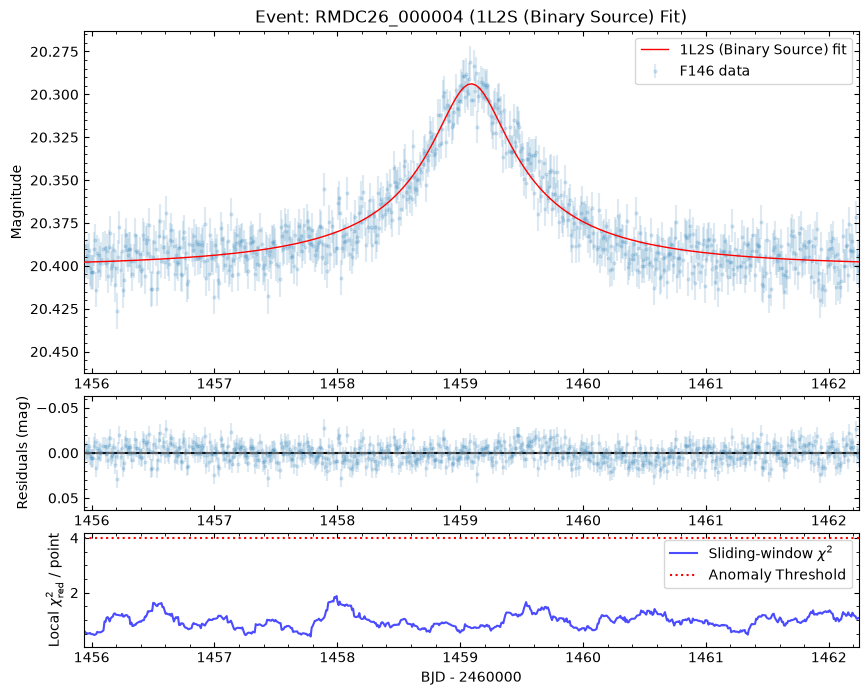

In [ ]:
### PLOTTING FOR INDIVIDUAL LIGHTCURVE ANALYSIS ###

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.12)

ax_top = fig.add_subplot(gs[0])
ax_mid = fig.add_subplot(gs[1], sharex=ax_top)
ax_bot = fig.add_subplot(gs[2], sharex=ax_top)

# top panel Light Curve
plt.sca(ax_top)
fit_data.plot(phot_fmt="mag", subtract_2460000=True, alpha=0.15, zorder=1, label=f"{fit_band} data", ms=2)
# Set time bounds around t_0 ± N * t_E (clipped to actual dataset start/end)
N_TE = 10.0
t_min_data, t_max_data = fit_data.time.min(), fit_data.time.max()
t_start = max(t_min_data, t_0_fit - N_TE * t_E_fit)
t_stop = min(t_max_data, t_0_fit + N_TE * t_E_fit)
best_event.plot_model(phot_fmt="mag", subtract_2460000=True, t_start=t_start, t_stop=t_stop, color="red", linewidth=1, zorder=10, label=f"{model_type} fit")
ax_top.legend(loc="upper right")
ax_top.set_ylabel("Magnitude")
ax_top.set_title(f"Event: {event_id} ({model_type} Fit)")

# middle panel Residuals
plt.sca(ax_mid)
best_event.plot_residuals(subtract_2460000=True, zorder=1, ms=2, alpha=0.15)
ax_mid.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax_mid.set_ylabel("Residuals (mag)")

# bottom Panel: Sliding-window chi2 profile
plt.sca(ax_bot)
ax_bot.plot(df_chi2["bjd"] - 2460000, df_chi2["rolling_chi2"], color="blue", label=r"Sliding-window $\chi^2$", alpha=0.7)
ax_bot.axhline(anomaly_threshold, color="red", linestyle=":", label="Anomaly Threshold")
ax_bot.fill_between(
    df_chi2["bjd"] - 2460000,
    df_chi2["rolling_chi2"],
    anomaly_threshold,
    where=df_chi2["rolling_chi2"] > anomaly_threshold,
    color="red",
    alpha=0.3,
)
ax_bot.set_xlabel("BJD - 2460000")
ax_bot.set_ylabel(r"Local $\chi^2_{\mathrm{red}}$ / point")
ax_bot.legend(loc="upper right")

# zoom around peak (t_0 ± 1.5 t_E)
zoom_margin = 1.5 * t_E_fit
ax_top.set_xlim((t_0_fit - zoom_margin) - 2460000, (t_0_fit + zoom_margin) - 2460000)

plt.show()